<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Similitud Semantica con Word2Vec</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Aplicar Word2Vec para calcular similitud semantica y encontrar palabras analogas.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrena un modelo Word2Vec con el corpus provisto (shakespeare.txt)</li>
<li>Encuentra las 5 palabras mas similares a palabras clave (crooked ----> 5 plbras mas similares)</li>
<li>Calcula similitudes entre grupos de palabras ([imperfections, devout, ascend] ---> [[]])</li>
<li>Visualiza los embeddings con PCA (reducir a 2 dimensiones o a 3)</li>
<li>Construye un sistema de busqueda semantica simple</li>

</ul>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings
from gensim.models import Word2Vec
import re
from gensim.models import FastText
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
# Calcular similitud coseno entre pares
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize, sent_tokenize
from NLPTextCleaning import NLPTextCleaning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\iscer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\iscer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
import re                                                           # Cargando los datos del archivo de texto
with open('shakespeare.txt') as f:
    data = f.read()


In [4]:
nplCleanning = NLPTextCleaning(idioma='english')
textProcesado=nplCleanning.preprocesar(data)
sentences = nplCleanning.tokenizar_oraciones(textProcesado)
sentences

[['for',
  'muse',
  'of',
  'fire',
  'that',
  'would',
  'ascend',
  'the',
  'brightest',
  'heaven',
  'of',
  'invention',
  'kingdom',
  'for',
  'stage',
  'princes',
  'to',
  'act',
  'and',
  'monarchs',
  'to',
  'behold',
  'the',
  'swelling',
  'scene',
  'then',
  'should',
  'the',
  'warlike',
  'harry',
  'like',
  'himself',
  'assume',
  'the',
  'port',
  'of',
  'mars',
  'and',
  'at',
  'his',
  'heels',
  'leash',
  'in',
  'like',
  'hounds',
  'should',
  'famine',
  'sword',
  'and',
  'fire',
  'crouch',
  'for',
  'employment',
  'but',
  'pardon',
  'and',
  'gentles',
  'all',
  'the',
  'flat',
  'unraised',
  'spirits',
  'that',
  'have',
  'dared',
  'on',
  'this',
  'unworthy',
  'scaffold',
  'to',
  'bring',
  'forth',
  'so',
  'great',
  'an',
  'object',
  'can',
  'this',
  'cockpit',
  'hold',
  'the',
  'vasty',
  'fields',
  'of',
  'france',
  'or',
  'may',
  'we',
  'cram',
  'within',
  'this',
  'wooden',
  'the',
  'very',
  'casque

In [5]:
# Entrenar Word2Vec 
model_w2v = Word2Vec(sentences = sentences, vector_size = 50, window=3, min_count = 1, sg = 1, epochs = 200, seed = 42)

In [6]:
palabras_query = ['bright', 'brighter', 'light', 'sun', 'moon', 'star', 'heaven']

def get_word_similar(parText):
    if parText in model_w2v.wv:
        similares = model_w2v.wv.most_similar(parText, topn=5)
        return similares
    else:
        return None

print("="*20,"Palabras similares","="*20)
for palabra in palabras_query: 
    res = get_word_similar(palabra)
    if res:
        for i, (palabra_similar, score) in enumerate(res, 1):
                print(f"  {i}. {palabra} --{palabra_similar:<15} (similitud: {score:.4f})")
    else:
        print(f"Palabra : {palabra} No encontrada")
        

==================== Palabras similares ====================
  1. bright --darkly          (similitud: 0.7481)
  2. bright --nights          (similitud: 0.7066)
  3. bright --dark            (similitud: 0.6876)
  4. bright --contents        (similitud: 0.6816)
  5. bright --dreams          (similitud: 0.6533)
Palabra : brighter No encontrada
  1. light --clearer         (similitud: 0.7959)
  2. light --unseeing        (similitud: 0.7869)
  3. light --disposed        (similitud: 0.7867)
  4. light --crawls          (similitud: 0.7731)
  5. light --maturity        (similitud: 0.7091)
  1. sun --moon            (similitud: 0.7086)
  2. sun --staineth        (similitud: 0.7069)
  3. sun --spent           (similitud: 0.6857)
  4. sun --delights        (similitud: 0.6856)
  5. sun --loathsome       (similitud: 0.6844)
  1. moon --loathsome       (similitud: 0.9056)
  2. moon --sunken          (similitud: 0.8647)
  3. moon --bottom          (similitud: 0.8588)
  4. moon --ooze            (sim

In [7]:
print("="*20,"Similitud entre un grupo de palabras","="*20)

def get_group_similar(parList):
    res_similares = []
    for palabra in parList:
        if palabra in model_w2v.wv:
            similares = model_w2v.wv.most_similar(palabra, topn=5)
            res =[]
            for i, (palabra_similar, score) in enumerate(similares, 1):
                 res.append((palabra_similar,score))
            res_similares.append((palabra,res))
        else:
             res_similares.append((palabra,None))
    return res_similares
    
palabras_query = ['bright', 'brighter', 'light', 'sun', 'moon', 'star', 'heaven']

res = get_group_similar(palabras_query)
for palabra,res in res:
    if res:
        for palabra_similar, score in res:
             print(f"  {i}. {palabra} --{palabra_similar:<15} (similitud: {score:.4f})")
    else:
         print(f"Palabra : {palabra} No encontrada")


==================== Similitud entre un grupo de palabras ====================
  5. bright --darkly          (similitud: 0.7481)
  5. bright --nights          (similitud: 0.7066)
  5. bright --dark            (similitud: 0.6876)
  5. bright --contents        (similitud: 0.6816)
  5. bright --dreams          (similitud: 0.6533)
Palabra : brighter No encontrada
  5. light --clearer         (similitud: 0.7959)
  5. light --unseeing        (similitud: 0.7869)
  5. light --disposed        (similitud: 0.7867)
  5. light --crawls          (similitud: 0.7731)
  5. light --maturity        (similitud: 0.7091)
  5. sun --moon            (similitud: 0.7086)
  5. sun --staineth        (similitud: 0.7069)
  5. sun --spent           (similitud: 0.6857)
  5. sun --delights        (similitud: 0.6856)
  5. sun --loathsome       (similitud: 0.6844)
  5. moon --loathsome       (similitud: 0.9056)
  5. moon --sunken          (similitud: 0.8647)
  5. moon --bottom          (similitud: 0.8588)
  5. moon --oo

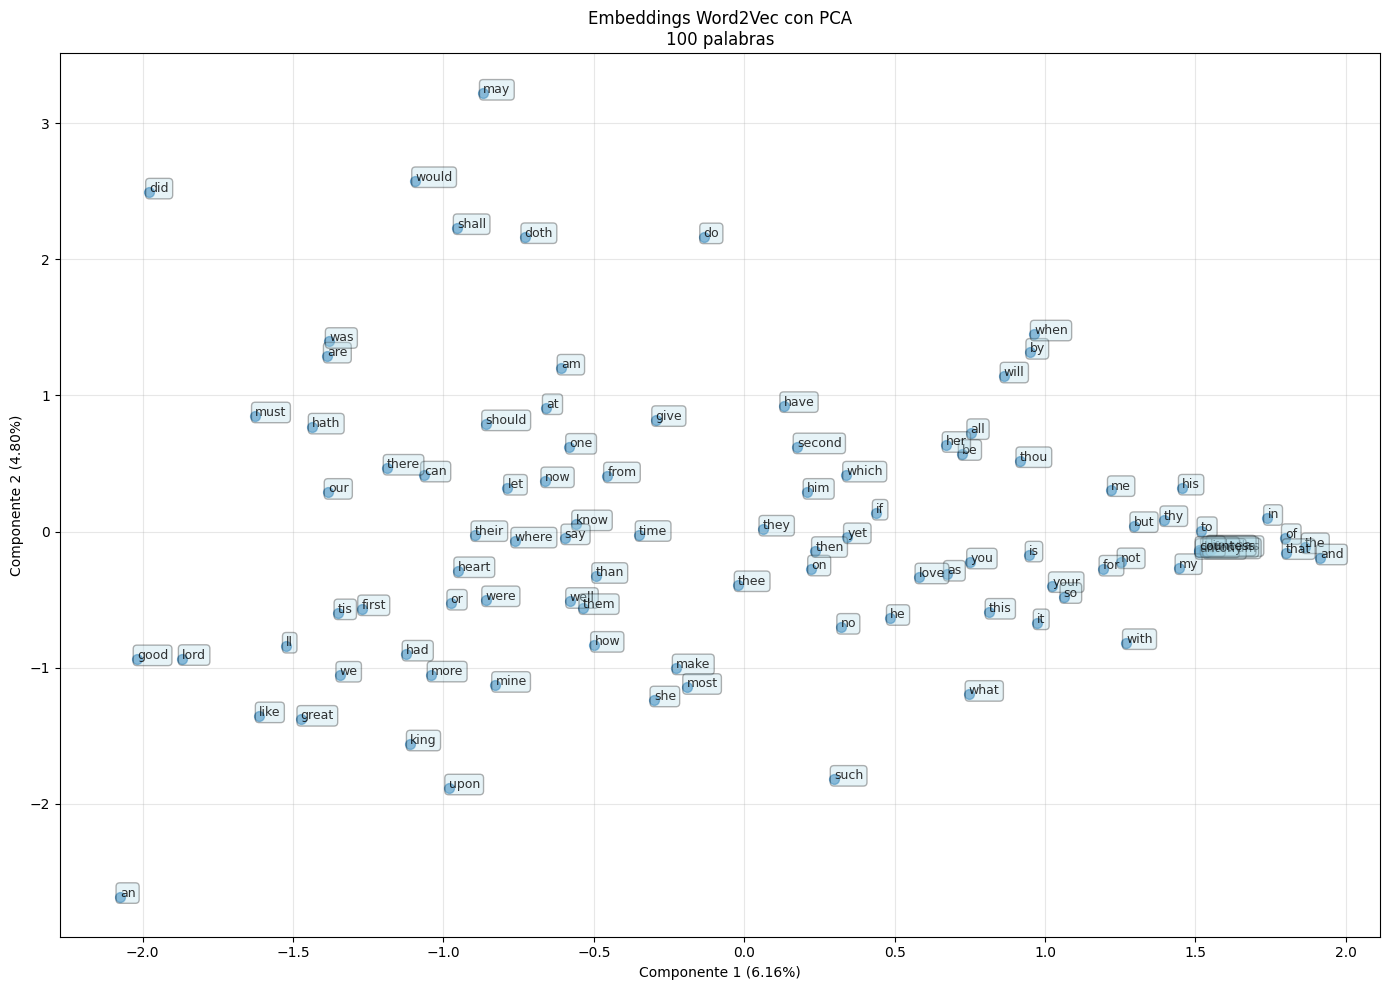

In [9]:
def visualizar_embeddings_2d(model, palabras=None, topn=100):
    
    palabras = model.wv.index_to_key[:topn]#100 palabras del modelo
    vectores = np.array([model.wv[p] for p in palabras])
    # PCA a 2 dimensiones
    pca = PCA(n_components=2)
    vectores_2d = pca.fit_transform(vectores)
    
    # Plotear palabras 
    plt.figure(figsize=(14, 10))
    plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1], alpha=0.6, s=50)

    for i, palabra in enumerate(palabras):
        plt.annotate(palabra, 
                    (vectores_2d[i, 0], vectores_2d[i, 1]),
                    fontsize=9,
                    alpha=0.8,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.3))
    
    plt.title(f'Embeddings Word2Vec con PCA\n{len(palabras)} palabras',fontsize=12)
    plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]:.2%})')#cuando se reduce el vector a 2 dimensiones esto dice cual es el % de perdida de información
    plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return vectores_2d, pca

# Visualizar primeras 100 palabras
vectores_2d, pca = visualizar_embeddings_2d(model_w2v, topn=100)

In [40]:
#  Motor de búsqueda semántica con Word2Vec 
print("="*20,"Buscador semantico","="*20)
print("="*20,"Busca por palabra en las oraciones del texto","="*20)
class BuscadorSemantico:
    """Búsqueda semántica usando embeddings promediados de Word2Vec."""

    def __init__(self, corpus, modelo):
        self.corpus = corpus
        self.modelo = modelo
        self.embeddings = [self.sentence_embedding_avg(doc, modelo) for doc in corpus]
        self.embeddings = np.array(self.embeddings )
    
    def sentence_embedding_avg(self,oracion, modelo):
        """Promedia los embeddings de las palabras de la oración."""
        tokens = re.findall(r'[a-záéíóúüñ]+', oracion.lower())
        vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
        if not vecs:
            return np.zeros(modelo.vector_size)
        return np.mean(vecs, axis=0)

    def buscar(self, query, top_n=3):
        q_emb = self.sentence_embedding_avg(query, self.modelo)
        if np.linalg.norm(q_emb) == 0:
            return []
        q_emb = q_emb/np.linalg.norm(q_emb)
        norms = np.linalg.norm(self.embeddings, axis=1, keepdims = True)
        norms_emb = self.embeddings/(norms+1e-8)

        sims = norms_emb@q_emb

        indices = sims.argsort()[::-1][:top_n]
        return [(i, sims[i], self.corpus[i]) for i in indices]

corpus = data.split(', ')#Se tokeniza todo el texto por oraciones separadas por ","
buscador = BuscadorSemantico(corpus, model_w2v)
query =["can","let","swelling"]
for q in query:
    resultados = buscador.buscar(q, top_n = 5)
    print(f'\nPalabra: {q}')
    for rank, (idx, score, doc) in enumerate(resultados, 1):
        print(f'[{rank}] sim = {score} | {doc}')

==================== Buscador semantico ====================
==================== Busca por palabra en las oraciones del texto ====================

Palabra: can
[1] sim = 0.7769086286948791 | farewell; if I can remember thee
[2] sim = 0.7555919618976256 | can settle
    The heart of Antony
[3] sim = 0.7117633888593808 | if I can
    meet him with any convenience
[4] sim = 0.7011900830308508 | when such a mutual pair
    And such a twain can do't
[5] sim = 0.6976747882360217 | you can eat none of this homely meat.
  CLOWN. O Lord

Palabra: let
[1] sim = 0.8161532190686579 | sir; let it satisfy you
[2] sim = 0.7590311968665995 | let me live
[3] sim = 0.71919352381089 | let their bodies follow
[4] sim = 0.715601536123333 | let's return again
[5] sim = 0.7071273937763454 | very good; let it
    be conceal'd awhile.
  BERTRAM. Undone

Palabra: swelling
[1] sim = 0.87156988496863 | princes to act
And monarchs to behold the swelling scene!
Then should the warlike Harry
[2] sim = 0.7250886710